# Who are the bank's customers? Segmenting 45,000 clients with K-means

A Portuguese bank phoned 45,211 clients to offer a term deposit (the data comes from a real telemarketing campaign, 2008-2010). This notebook groups the clients into **segments** with K-means clustering, using only *who they are* (age, balance, job, family situation, loans), and then asks the question that makes a segmentation useful or useless: **do the segments behave differently?** The campaign outcome is deliberately kept out of the clustering, so it can serve as an independent test.

The steps: prepare mixed numeric and categorical data, choose the number of clusters with the elbow and silhouette methods, check that the clusters are stable, profile them, and compare their power to predict who subscribes against much simpler groupings such as age bands.

**Data:** [Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) from the UCI Machine Learning Repository (Moro, Cortez and Rita, 2014; CC BY 4.0). The notebook downloads it (about 1 MB) into `BANK_DIR` on the first run.

In [1]:
import io
import os
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, roc_auc_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_DIR = Path(os.environ.get("BANK_DIR", "bank_data"))
DATA_DIR.mkdir(exist_ok=True)
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
PALETTE = [AMBER, BLUE, "#38a169", "#c0392b", "#805ad5", "#17a2b8", "#4a5568", "#d4ac0d"]
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})

## 1. Load the clients

In [2]:
zip_path = DATA_DIR / "bank_marketing.zip"
if not zip_path.exists():
    urllib.request.urlretrieve("https://archive.ics.uci.edu/static/public/222/bank+marketing.zip", zip_path)
with zipfile.ZipFile(zip_path) as outer:
    inner = zipfile.ZipFile(io.BytesIO(outer.read("bank.zip")))
    df = pd.read_csv(inner.open("bank-full.csv"), sep=";")
df["subscribed"] = (df.y == "yes").astype(int)
print(f"{len(df):,} clients, {df.subscribed.mean():.1%} subscribed to the term deposit")
df.head(4)

45,211 clients, 11.7% subscribed to the term deposit


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,subscribed
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0


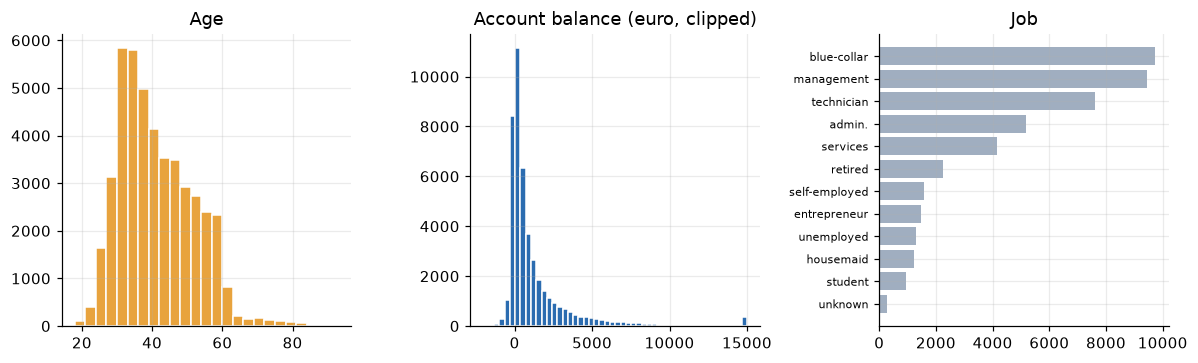

,age,balance
count,45211.0,45211.0
mean,41.0,1362.0
std,11.0,3045.0
min,18.0,-8019.0
25%,33.0,72.0
50%,39.0,448.0
75%,48.0,1428.0
max,95.0,102127.0


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
axes[0].hist(df.age, bins=range(18, 96, 3), color=AMBER, edgecolor="white")
axes[0].set_title("Age")
axes[1].hist(df.balance.clip(-2000, 15000), bins=50, color=BLUE, edgecolor="white")
axes[1].set_title("Account balance (euro, clipped)")
job = df.job.value_counts()
axes[2].barh(job.index[::-1], job.values[::-1], color=GREY)
axes[2].set_title("Job")
axes[2].tick_params(axis="y", labelsize=7)
fig.tight_layout()
plt.show()
df[["age", "balance"]].describe().round(0)

## 2. Prepare the features

Only the client's **profile** goes into the clustering: age, balance, job, marital status, education, credit default, housing loan and personal loan. The columns describing the phone calls (`duration`, `campaign`, `pdays`, `previous`, `poutcome`, `contact`, `month`) and the outcome are left out, because they describe the campaign, not the client (and `duration` is only known after the call).

K-means measures distances, so the features have to be comparable:

- **Balance** is extremely skewed (a few clients hold hundreds of thousands), so it is replaced by a signed logarithm.
- Numbers are standardised (mean 0, spread 1).
- Categories become one-hot columns, down-weighted by half so that a single category label does not outweigh a full standard deviation of age or balance.

K-means is not designed for categorical data, which is a real limitation, and the last section checks how much it matters.

In [4]:
df["balance_log"] = np.sign(df.balance) * np.log1p(df.balance.abs())
NUMERIC = ["age", "balance_log"]
CATEGORICAL = ["job", "marital", "education", "default", "housing", "loan"]

numeric = StandardScaler().fit_transform(df[NUMERIC])
encoder = OneHotEncoder(sparse_output=False).fit(df[CATEGORICAL])
categorical = encoder.transform(df[CATEGORICAL]) * 0.5
X = np.hstack([numeric, categorical])
print(f"feature matrix: {X.shape[0]:,} clients x {X.shape[1]} columns")

feature matrix: 45,211 clients x 27 columns


## 3. How many segments?

Two standard diagnostics for K-means, computed for 2 to 10 clusters:

- **Inertia (elbow)**: the total squared distance to the cluster centres. It always falls as clusters are added; the useful number is where the fall slows down.
- **Silhouette**: how well each client fits its own cluster compared with the next-nearest one (from -1 to 1, higher is better). It is computed on a 6,000-client sample because it is slow on all rows.

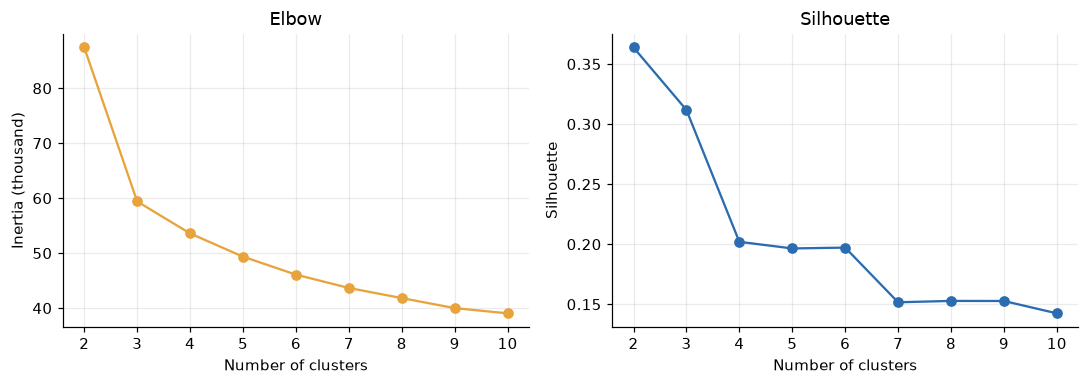

k,2,3,4,5,6,7,8,9,10
inertia,87427.666,59407.071,53585.904,49357.502,46090.661,43664.163,41819.511,39996.049,39044.159
silhouette,0.364,0.312,0.202,0.196,0.197,0.152,0.153,0.153,0.142


In [5]:
rows = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=5, random_state=0).fit(X)
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(X, km.labels_, sample_size=6000, random_state=0)})
selection = pd.DataFrame(rows).set_index("k")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(selection.index, selection.inertia / 1000, marker="o", color=AMBER)
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Inertia (thousand)")
axes[0].set_title("Elbow")
axes[1].plot(selection.index, selection.silhouette, marker="o", color=BLUE)
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Silhouette")
axes[1].set_title("Silhouette")
fig.tight_layout()
plt.show()
selection.round(3).T

There is no sharp elbow, and the silhouette is highest for just two clusters (0.36) and drops to about 0.2 from four clusters on: the clients form **a continuum, not clearly separated groups**. That is normal for real customer data, and it means the number of segments is a business choice as much as a statistical one. Two segments would be statistically tidiest but too coarse to act on, so six are used below, enough to be descriptive while still small enough to manage.

In [6]:
K = 6
km = KMeans(n_clusters=K, n_init=20, random_state=0).fit(X)
# number the segments by average age so that Segment 1 is the youngest
order = df.groupby(km.labels_).age.mean().sort_values().index
relabel = {old: new + 1 for new, old in enumerate(order)}
df["segment"] = pd.Series(km.labels_).map(relabel).to_numpy()
df.segment.value_counts().sort_index().to_frame("clients").assign(share=lambda d: (d.clients / len(df)).round(3))

,clients,share
segment,,
1,15257,0.337
2,4039,0.089
3,2969,0.066
4,12442,0.275
5,2464,0.055
6,8040,0.178


## 4. Stability: would the segments come out the same again?

Clusters that change every time the algorithm restarts, or when the data is resampled a little, are not worth acting on. The **adjusted Rand index** (ARI) compares two clusterings: 1 means identical, 0 means no better than chance. Here K-means is run with ten different random starts, and again on ten bootstrap resamples of the clients.

In [7]:
rng = np.random.default_rng(1)
restarts = [KMeans(n_clusters=K, n_init=1, random_state=s).fit(X).labels_ for s in range(10)]
restart_ari = [adjusted_rand_score(km.labels_, labels) for labels in restarts]

boot_ari = []
for _ in range(10):
    idx = rng.choice(len(X), size=len(X), replace=True)
    boot = KMeans(n_clusters=K, n_init=3, random_state=0).fit(X[idx])
    boot_ari.append(adjusted_rand_score(km.labels_, boot.predict(X)))
pd.DataFrame({"ARI vs the final clustering": [np.mean(restart_ari), np.mean(boot_ari)],
              "lowest": [np.min(restart_ari), np.min(boot_ari)]},
             index=["10 random restarts", "10 bootstrap resamples"]).round(3)

,ARI vs the final clustering,lowest
10 random restarts,0.703,0.338
10 bootstrap resamples,0.729,0.462


## 5. Profile the segments

What does a typical client in each segment look like? Medians are used for balance because of the skew.

In [8]:
def top_share(s):
    vc = s.value_counts(normalize=True)
    return f"{vc.index[0]} ({vc.iloc[0]:.0%})"

profile = df.groupby("segment").agg(
    clients=("age", "size"),
    mean_age=("age", "mean"),
    median_balance=("balance", "median"),
    housing_loan=("housing", lambda s: (s == "yes").mean()),
    personal_loan=("loan", lambda s: (s == "yes").mean()),
    married=("marital", lambda s: (s == "married").mean()),
    tertiary=("education", lambda s: (s == "tertiary").mean()),
    top_job=("job", top_share),
)
profile["share"] = profile.clients / len(df)
profile.round(2)

,clients,mean_age,median_balance,housing_loan,personal_loan,married,tertiary,top_job,share
segment,,,,,,,,,
1,15257,31.43,616.0,0.60,0.14,0.41,0.37,management (23%),0.34
2,4039,34.38,0.0,0.56,0.17,0.55,0.32,management (22%),0.09
3,2969,36.49,-256.0,0.78,0.32,0.57,0.19,blue-collar (31%),0.07
4,12442,43.09,734.5,0.61,0.15,0.73,0.26,blue-collar (26%),0.28
5,2464,52.84,0.0,0.39,0.21,0.72,0.25,management (20%),0.05
6,8040,56.92,975.0,0.35,0.14,0.77,0.25,retired (23%),0.18


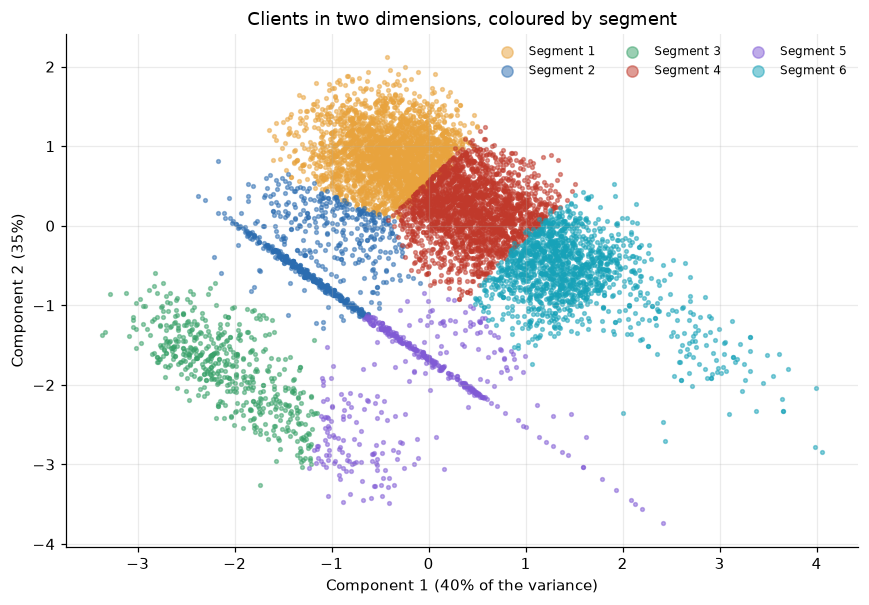

In [9]:
sample = df.sample(8000, random_state=0)
pca = PCA(n_components=2, random_state=0).fit(X)
xy = pca.transform(X[sample.index])
fig, ax = plt.subplots(figsize=(8, 5.6))
for seg, color in zip(sorted(df.segment.unique()), PALETTE):
    m = (sample.segment == seg).to_numpy()
    ax.scatter(xy[m, 0], xy[m, 1], s=6, alpha=0.5, color=color, label=f"Segment {seg}")
ax.set_xlabel(f"Component 1 ({pca.explained_variance_ratio_[0]:.0%} of the variance)")
ax.set_ylabel(f"Component 2 ({pca.explained_variance_ratio_[1]:.0%})")
ax.set_title("Clients in two dimensions, coloured by segment")
ax.legend(frameon=False, markerscale=3, ncol=3, fontsize=8)
fig.tight_layout()
plt.show()

## 6. Do the segments behave differently?

The test the clustering never saw: the share of each segment that subscribed to the term deposit, with a 95% confidence interval (the Wilson interval, which behaves well for small groups). A useful segmentation should show clearly different rates.

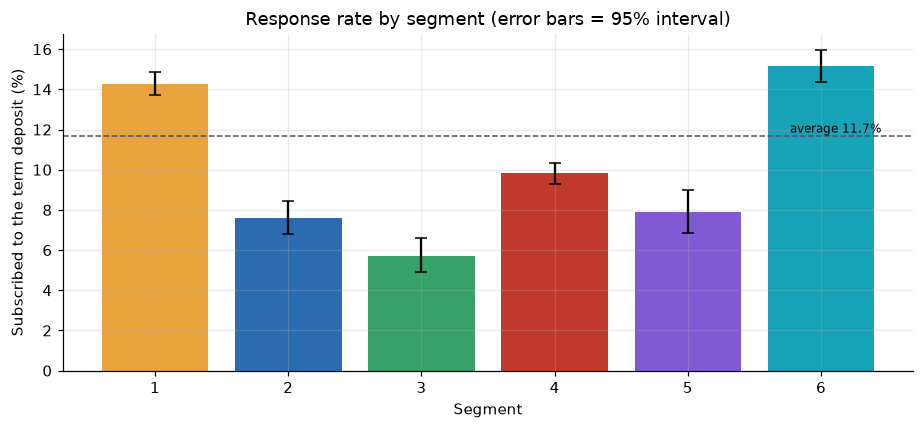

,subscribed,clients,rate,ci_low,ci_high,lift
segment,,,,,,
1,2180,15257,0.143,0.137,0.149,1.221
2,306,4039,0.076,0.068,0.084,0.648
3,169,2969,0.057,0.049,0.066,0.487
4,1222,12442,0.098,0.093,0.104,0.840
5,194,2464,0.079,0.069,0.090,0.673
6,1218,8040,0.151,0.144,0.159,1.295


In [10]:
def wilson(successes, n, z=1.96):
    p = successes / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return centre - half, centre + half

overall = df.subscribed.mean()
by_segment = df.groupby("segment").subscribed.agg(["sum", "size"])
by_segment["rate"] = by_segment["sum"] / by_segment["size"]
ci = np.array([wilson(s, n) for s, n in zip(by_segment["sum"], by_segment["size"])])
by_segment["ci_low"], by_segment["ci_high"] = ci[:, 0], ci[:, 1]
by_segment["lift"] = by_segment.rate / overall

fig, ax = plt.subplots(figsize=(8.5, 4))
x = by_segment.index
ax.bar(x, by_segment.rate * 100, color=PALETTE[:len(x)], yerr=[(by_segment.rate - by_segment.ci_low) * 100, (by_segment.ci_high - by_segment.rate) * 100],
       capsize=4)
ax.axhline(overall * 100, color="#4a5568", ls="--", lw=1)
ax.text(x.max() + 0.45, overall * 100, f"average {overall:.1%}", va="bottom", ha="right", fontsize=8)
ax.set_xlabel("Segment")
ax.set_ylabel("Subscribed to the term deposit (%)")
ax.set_title("Response rate by segment (error bars = 95% interval)")
fig.tight_layout()
plt.show()
by_segment.rename(columns={"sum": "subscribed", "size": "clients"}).round(3)

## 7. Is K-means better than something simple?

A segmentation earns its complexity only if it separates responders better than an obvious grouping. Five alternatives are compared as a **targeting score**: each client is scored with the subscription rate of their group, measured on a training 70% of the clients, and the score is judged by ROC AUC on the unseen 30% (0.5 = no better than random, 1 = perfect). The groupings are the K-means segments, five age bands, the job, whether the client has a housing loan, and six groups assigned **at random** (the baseline that shows what pure noise looks like).

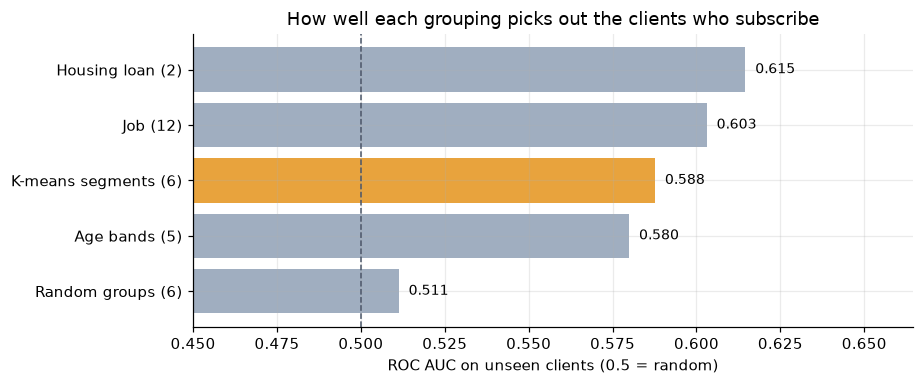

,AUC
Random groups (6),0.511
Age bands (5),0.580
K-means segments (6),0.588
Job (12),0.603
Housing loan (2),0.615


In [11]:
idx_train, idx_test = train_test_split(df.index, test_size=0.3, stratify=df.subscribed, random_state=0)
y = df.subscribed

def targeting_auc(groups):
    rates = y[idx_train].groupby(groups[idx_train]).mean()
    score = groups[idx_test].map(rates).fillna(y[idx_train].mean())
    return roc_auc_score(y[idx_test], score)

alternatives = {
    "K-means segments (6)": df.segment,
    "Age bands (5)": pd.cut(df.age, [0, 29, 39, 49, 59, 120]).astype(str),
    "Job (12)": df.job,
    "Housing loan (2)": df.housing,
    "Random groups (6)": pd.Series(np.random.default_rng(0).integers(0, 6, len(df)), index=df.index),
}
auc = pd.Series({name: targeting_auc(g) for name, g in alternatives.items()}).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.barh(auc.index, auc.values, color=[AMBER if n.startswith("K-means") else GREY for n in auc.index])
for y_, v in enumerate(auc.values):
    ax.text(v + 0.003, y_, f"{v:.3f}", va="center", fontsize=9)
ax.axvline(0.5, color="#4a5568", ls="--", lw=1)
ax.set_xlim(0.45, auc.max() + 0.05)
ax.set_xlabel("ROC AUC on unseen clients (0.5 = random)")
ax.set_title("How well each grouping picks out the clients who subscribe")
fig.tight_layout()
plt.show()
auc.round(3).to_frame("AUC")

## What the results say

- **The clients form a continuum, not neat groups.** The silhouette is 0.36 for two clusters and about 0.2 for four or more, and the elbow plot has no sharp bend. Six segments were chosen as a balance between detail and usability, not because the data demanded it.
- **The segments are moderately stable.** Across ten random restarts the clustering agrees with the final one at an adjusted Rand index of 0.70 (the worst restart 0.34), and across ten bootstrap resamples at 0.73 (worst 0.46). The broad picture is repeatable but the boundaries between neighbouring segments move.
- **The six segments are mainly age, balance and loans.** Segment 1 (34% of clients, average age 31) is young, 60% have a housing loan and management is the top job. Segments 2 and 5 are mostly clients with a **zero balance** (median 0) aged 34 and 53 respectively, which shows up as the diagonal streak in the two-dimensional map. Segment 3 (7%, age 36) is the indebted group: median balance -256 euro, 78% with a housing loan, 32% with a personal loan, mostly blue-collar workers with the lowest share of tertiary education (19%). Segment 4 (28%, age 43) is married blue-collar clients. Segment 6 (18%, age 57) is the oldest and most comfortable group, with a median balance of 975 euro, few housing loans (35%) and retired clients as the top group.
- **The segments do respond differently, in a U-shape.** 14.3% of segment 1 (the youngest) and 15.1% of segment 6 (the oldest) subscribed, against 11.7% overall, while the indebted segment 3 responded least (5.7%, less than half the average). The 95% intervals of segments 1 and 6 sit clearly above the average and those of segments 2, 3, 4 and 5 clearly below.
- **But the segmentation is not a better targeting tool than something simple.** Scoring clients by their group's historical response, K-means segments reach a ROC AUC of 0.588 on unseen clients. Five age bands get 0.580, the job 0.603, and a single yes/no question, whether the client has a housing loan, gets 0.615. Random groups get 0.511 as expected. The segments are useful for *describing* the customer base, but for picking who to call they add little over the simple variables they were built from.
- **The strongest signals were deliberately left out.** The columns describing the calls themselves (duration, number of contacts, earlier campaign outcome) are typically the strongest predictors of subscription in this dataset (this notebook does not test that), but they describe the campaign, not the client, and were excluded from the clustering.

**Limits:** K-means works with distances, so mixing standardised numbers with half-weighted one-hot columns is a compromise; algorithms designed for mixed data (K-Prototypes, Gower distance with hierarchical clustering) might find different groups. The data is from a Portuguese bank in 2008-2010. Group response rates were estimated on 70% of the clients and scored on the other 30%.

**Techniques covered:** log transformation of skewed data, one-hot encoding and scaling, K-means with elbow and silhouette, stability with the adjusted Rand index and bootstrap, PCA for visualisation, Wilson confidence intervals, ROC AUC of a group-rate score against baselines.
